# Separação do Dataset Curado (Train, Val)

Este notebook executa o split final do dataset consolidado. Ele lê as imagens sobreviventes que estão na pasta `data/visual/` (as imagens que você escolheu manter) e as divide de forma aleatória e embaralhada em conjuntos de treino e validação para o treinamento do YOLO.

In [5]:
# Configura o path do projeto
import sys
import os
sys.path.append(os.path.abspath('..'))

## 1. Executar a Separação (Split)

Abaixo definimos as proporções de separação (`80% Treino / 20% Validação` por padrão) e executamos o script `src/data/split.py`.

In [6]:
from src.data.split import run_split

# Executa a separação (base_dir='..' indica que a pasta raiz do projeto está um nível acima)
run_split(train_ratio=0.8, val_ratio=0.2, seed=42, base_dir='..')

Total curated images in data/visual/: 3345
Traceability records matched: 3344 / 5419

Copying files to splits...
Finished copying 3344 images and labels.
Saved traceability_final CSV to ../data/metadata/traceability_final.csv
Saved unified data.yaml to ../data/dataset_final/data.yaml

           SPLIT STATISTICS
Total dataset: 3344
split
train    2675
val       669
Name: count, dtype: int64
----------------------------------------
Distribution per dataset source:
split                         train  val  train_%  val_%
original_dataset                                        
classificador-de-lixo             7    2     77.8   22.2
garbage-8uzha                  1447  367     79.8   20.2
garbage-byghu                    28    5     84.8   15.2
garbage-classification-oaf5d      0    1      0.0  100.0
garbage-mvzg3                   640  137     82.4   17.6
garbage-ylmfy                   190   56     77.2   22.8
trash-lstse                     127   32     79.9   20.1
wasteinsight-nopp5 

## 2. Análise Visual do Dataset Final

Vamos plotar gráficos para visualizar como os dados foram divididos e comprovar a distribuição dos datasets de origem.

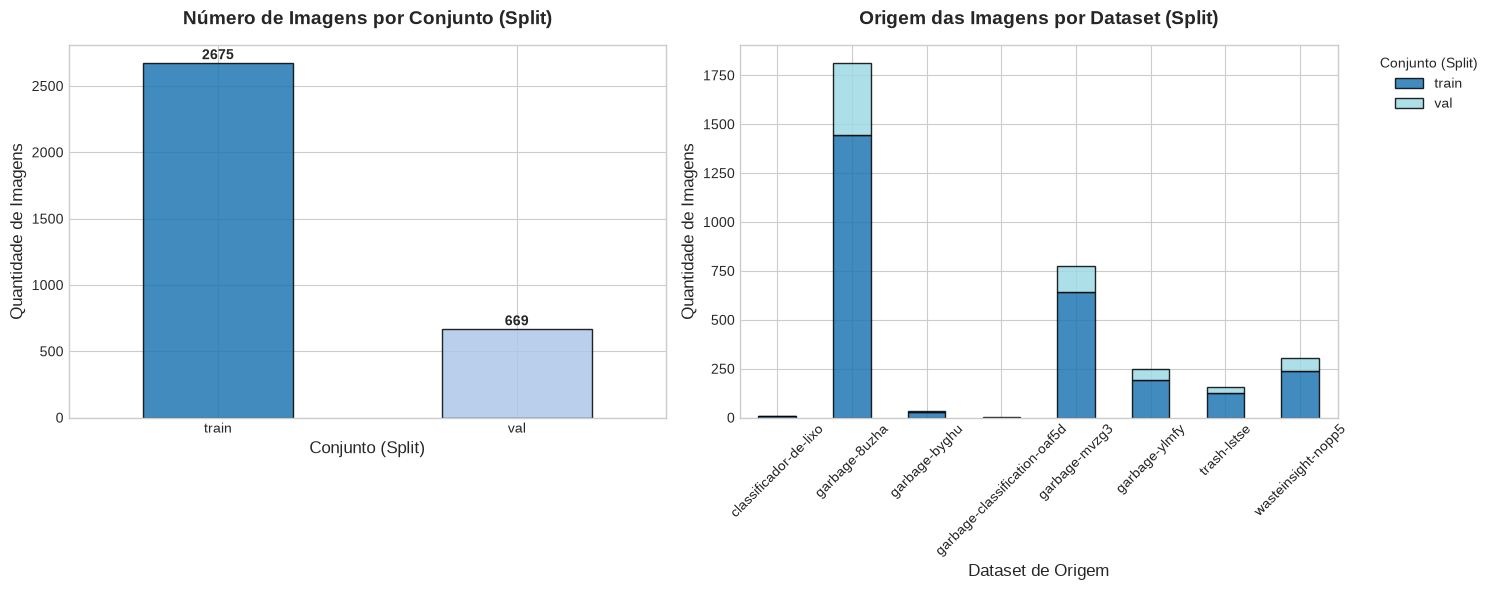

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

# Carrega a rastreabilidade final
df_final = pd.read_csv('../data/metadata/traceability_final.csv')

# Configura estilo visual dos gráficos
plt.style.use('seaborn-v0_8-whitegrid')
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Gráfico 1: Tamanho de cada split
split_counts = df_final['split'].value_counts().reindex(['train', 'val'])
colors = ['#1f77b4', '#aec7e8']
split_counts.plot(kind='bar', color=colors, ax=ax1, edgecolor='black', alpha=0.85)
ax1.set_title('Número de Imagens por Conjunto (Split)', fontsize=14, fontweight='bold', pad=15)
ax1.set_xlabel('Conjunto (Split)', fontsize=12)
ax1.set_ylabel('Quantidade de Imagens', fontsize=12)
ax1.tick_params(axis='x', rotation=0)
for i, val in enumerate(split_counts):
    if not pd.isna(val):
        ax1.text(i, val + (split_counts.max() * 0.01), str(int(val)), ha='center', fontweight='bold')

# Gráfico 2: Distribuição dos datasets de origem dentro de cada split
pivot = df_final.groupby(['original_dataset', 'split']).size().unstack(fill_value=0)
pivot = pivot[['train', 'val']]
pivot.plot(kind='bar', stacked=True, ax=ax2, colormap='tab20', edgecolor='black', alpha=0.85)
ax2.set_title('Origem das Imagens por Dataset (Split)', fontsize=14, fontweight='bold', pad=15)
ax2.set_xlabel('Dataset de Origem', fontsize=12)
ax2.set_ylabel('Quantidade de Imagens', fontsize=12)
ax2.tick_params(axis='x', rotation=45)
ax2.legend(title='Conjunto (Split)', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

### Detalhamento em Tabela

Esta tabela mostra exatamente a quantidade de imagens enviadas para cada split por base de dados de origem.

In [8]:
pivot_table = df_final.pivot_table(index='original_dataset', columns='split', aggfunc='size', fill_value=0)
pivot_table = pivot_table[['train', 'val']]
pivot_table['Total'] = pivot_table.sum(axis=1)

# Porcentagens aproximadas
for split in ['train', 'val']:
    pivot_table[f'{split}_%'] = (pivot_table[split] / pivot_table['Total'] * 100).round(1)
    
display(pivot_table[['train', 'train_%', 'val', 'val_%', 'Total']])

split,train,train_%,val,val_%,Total
original_dataset,,,,,
classificador-de-lixo,7,77.8,2,22.2,9
garbage-8uzha,1447,79.8,367,20.2,1814
garbage-byghu,28,84.8,5,15.2,33
garbage-classification-oaf5d,0,0.0,1,100.0,1
garbage-mvzg3,640,82.4,137,17.6,777
garbage-ylmfy,190,77.2,56,22.8,246
trash-lstse,127,79.9,32,20.1,159
wasteinsight-nopp5,236,77.4,69,22.6,305
